In [85]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [86]:
df = pd.read_csv("../data/telco_feature_engineered.csv")

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [88]:
binary_features = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'High_value_customer'
]

numeric_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'AvgMonthlySpend',
    'ContractLength',
    'TotalServices',
    'ChargePerService'
]

categorical_features = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod',
    'TenureGroup'
]

In [89]:
X.dtypes

gender                   int64
SeniorCitizen            int64
Partner                  int64
Dependents               int64
tenure                   int64
PhoneService             int64
MultipleLines              str
InternetService            str
OnlineSecurity             str
OnlineBackup               str
DeviceProtection           str
TechSupport                str
StreamingTV                str
StreamingMovies            str
Contract                   str
PaperlessBilling         int64
PaymentMethod              str
MonthlyCharges         float64
TotalCharges           float64
TenureGroup                str
AvgMonthlySpend        float64
High_value_customer      int64
ContractLength           int64
TotalServices            int64
ChargePerService       float64
dtype: object

In [90]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

### Logistic Regression Pipeline

In [91]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [92]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','SeniorCitizen','Partner',...,'ContractLength','TotalServices', 'ChargePerService']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [93]:
y_pred_lr= lr_pipeline.predict(X_test)

In [94]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



### DesicionTreeClassifier

In [95]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])


dt_pipeline.fit(X_train, y_train)
y_pred_2 = dt_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_2))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1033
           1       0.49      0.51      0.50       374

    accuracy                           0.73      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



### RandomForestClassifier

In [96]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            class_weight="balanced_subsample",
            n_estimators=100,
            random_state=42
        )
    )
])

param_dist_rf = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2"],
    "model__bootstrap": [True, False],
    "model__class_weight": ["balanced", "balanced_subsample"]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)


random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC:")
print(random_search.best_score_)

print("\nBest Estimator:")
print(random_search.best_estimator_)



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 8, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': 'balanced', 'model__bootstrap': True}

Best ROC-AUC:
0.8463963818053722

Best Estimator:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AvgMonthlySpend',
                                                   'ContractLength',
                                                   'TotalServices',
                                                   'ChargePerService']),
                                                 ('categorical',
                                                  OneHotEncod

In [97]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [98]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[741 292]
 [ 76 298]]


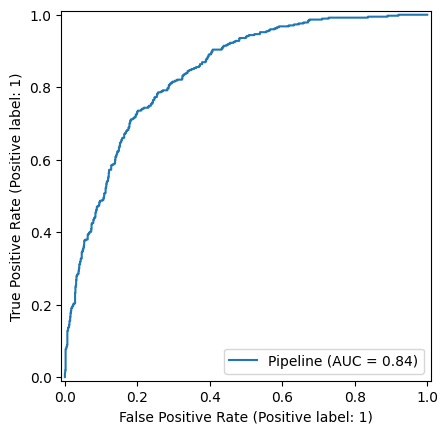

In [99]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_rf, X_test, y_test)

In [100]:
roc_auc_score(y_test,
              best_rf.predict_proba(X_test)[:,1])

0.8391489923435711

In [106]:
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

importances = best_rf.named_steps["model"].feature_importances_

In [109]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})
feature_importance.shape

(38, 2)

In [110]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
4,numeric__ContractLength,0.147594
0,numeric__tenure,0.107152
6,numeric__ChargePerService,0.092378
2,numeric__TotalCharges,0.085502
24,categorical__Contract_Two year,0.072932
1,numeric__MonthlyCharges,0.057071
3,numeric__AvgMonthlySpend,0.056842
9,categorical__InternetService_Fiber optic,0.055406
26,categorical__PaymentMethod_Electronic check,0.043114
30,categorical__TenureGroup_48-72,0.035478


### XGBoostClassifier

In [102]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    )
])
# param_grid_xgb = {
#     "model__n_estimators": [100, 200, 300],
#     "model__max_depth": [3, 5, 7],
#     "model__learning_rate": [0.01, 0.05, 0.1],
#     "model__subsample": [0.8, 1.0],
#     "model__colsample_bytree": [0.8, 1.0],
#     "model__gamma": [0, 0.1, 0.3]
# }
xgb_pipeline.fit(X_train, y_train)
y_pred_3 = xgb_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_3))


              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1033
           1       0.57      0.53      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.70      1407
weighted avg       0.76      0.77      0.77      1407



In [103]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    )
])
param_grid_xgb = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)
print("Best parameters found: ", grid_search_xgb.best_params_)
print("Best recall score found: ", grid_search_xgb.best_score_)
print("Best estimator found: ", grid_search_xgb.best_estimator_)

Best parameters found:  {'model__colsample_bytree': 1.0, 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best recall score found:  0.5344481605351171
Best estimator found:  Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'AvgMonthlySpend',
                                                   'ContractLength',
                                                   'TotalServices',
                                                   'ChargePerService']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle

In [104]:
best_model_xbg = grid_search_xgb.best_estimator_

y_pred = best_model_xbg.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407

